# Bedrock + LangGraph — minimal agent skeleton

**Milestone 1 of your stack:** orchestration (LangGraph) running locally, inference on **Bedrock** (data stays in your AWS boundary). No sandboxing yet — the tools below run *in this notebook process on purpose*, so you can learn the agent loop with nothing else moving. Cloudflare execution isolation comes later, once you have a tool worth isolating.

**How to use this notebook:** run the cells top to bottom once. After that, each piece is independent — edit a tool and re-run just its cell, then re-run the *Run the agent* cell to try it. No need to restart.


## 1. Install dependencies

Run once per environment. Skip if these are already installed. (The `%pip` magic installs into the kernel this notebook is actually using, which is what you want.)


In [ ]:
%pip install -q "langchain-aws>=1.4.5" "langgraph>=0.6" "langchain-core>=0.3" "boto3>=1.35.87"


## 2. Load credentials from `.env`

Inference happens on Bedrock, inside your AWS account/boundary. This skeleton authenticates with a **Bedrock API key** (a bearer token), which is the simplest path for local development — no full IAM credential setup required.

The cell below reads a `.env` file sitting next to this notebook and loads it into the environment. Put your key there:

```
AWS_BEARER_TOKEN_BEDROCK=your-bedrock-api-key-here
```

Generate the key in the Bedrock console under *API keys* (short-term or long-term). boto3 — which `ChatBedrockConverse` sits on — automatically detects the `AWS_BEARER_TOKEN_BEDROCK` environment variable when it builds the client, so there's nothing else to wire up. Run this cell **before** the import cell below, since the variable must be set first.

> Note: the key lives in a process-wide env var, so it's shared across threads — fine for local single-agent play, but it doesn't give per-client isolation if you later run many concurrent agents.


In [1]:
import os
from pathlib import Path


def load_dotenv(path: Path) -> None:
    """Read KEY=VALUE / 'export KEY=VALUE' lines from .env into os.environ.

    Anything already set in the real environment wins (setdefault), so a
    prior `export` / `source .env` still takes precedence.
    """
    if not path.exists():
        print(f"(no .env at {path} — relying on existing environment)")
        return
    for raw in path.read_text().splitlines():
        line = raw.strip().removeprefix("export ").strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        os.environ.setdefault(key.strip(), value.strip().strip("\"'"))


# In a notebook there's no __file__; use the current working directory.
load_dotenv(Path.cwd() / ".env")
print("AWS_BEARER_TOKEN_BEDROCK set:", "AWS_BEARER_TOKEN_BEDROCK" in os.environ)


AWS_BEARER_TOKEN_BEDROCK set: False


## 3. Config

Two things to set before the first real run:
- **`REGION`** — where you have Claude model access.
- **`MODEL_ID`** — a model you've enabled in the Bedrock console under *Model access*. If you get `AccessDenied` / model-not-enabled, enable it there or switch to one you already have. A cheaper Haiku option is in the comment for fast iteration.


In [2]:
REGION = "us-east-1"  # set to your region with Claude access

# Use an inference-profile / model ID you have enabled in Bedrock. Examples:
#   "us.anthropic.claude-sonnet-4-5-20250929-v1:0"   (cross-region inference profile)
#   "anthropic.claude-3-5-haiku-20241022-v1:0"        (cheaper, for iterating)
MODEL_ID = "us.anthropic.claude-sonnet-4-5-20250929-v1:0"

## 4. Define tools

Plain Python functions. The `@tool` decorator turns the docstring + signature into the schema the model sees when deciding whether to call them. Keep them trivial for now — their job is to prove the reason → tool → reason loop works.

**Edit these and re-run this cell** to experiment; then re-run the *Run the agent* cell.


In [3]:
from langchain_core.tools import tool


@tool
def calculator(expression: str) -> str:
    """Evaluate a basic arithmetic expression, e.g. '47 * 89' or '(3+4)/2'.

    Only supports numbers and the operators + - * / ( ) . — nothing else.
    """
    allowed = set("0123456789+-*/(). ")
    if not set(expression) <= allowed:
        return "Error: only numbers and + - * / ( ) . are allowed."
    try:
        # Locked-down eval: no builtins, no names. Fine for a local demo tool.
        # (When this becomes a real code-running tool, that's your cue to move
        # it into a Cloudflare sandbox instead of eval-ing in-process.)
        return str(eval(expression, {"__builtins__": {}}, {}))
    except Exception as e:
        return f"Error: {e}"


@tool
def get_weather(city: str) -> str:
    """Return a (fake, hardcoded) current weather report for a city.

    Stub so the agent has a second tool to choose between. Swap the body
    for a real API call when you're ready.
    """
    fake = {
        "houston": "Houston: 31°C, humid, partly cloudy.",
        "seattle": "Seattle: 14°C, light rain.",
        "denver": "Denver: 22°C, clear and dry.",
    }
    return fake.get(city.strip().lower(),
                    f"No demo data for '{city}'. Try Houston, Seattle, or Denver.")


# Quick offline sanity check — these run locally, no AWS needed:
print(calculator.invoke({"expression": "47 * 89"}))
print(get_weather.invoke({"city": "Houston"}))


4183
Houston: 31°C, humid, partly cloudy.


## 5. Build the agent

`create_react_agent` gives you the standard reason → act → observe loop without hand-drawing nodes and edges. When you outgrow it (custom routing, parallel branches, human-in-the-loop interrupts), you graduate to building the `StateGraph` yourself — same library, lower level.

Constructing the graph does **not** call Bedrock, so this cell works even before your credentials are set. The live call happens in the next cell.


In [4]:
from langchain_aws import ChatBedrockConverse
from langgraph.prebuilt import create_react_agent

llm = ChatBedrockConverse(
    model=MODEL_ID,
    region_name=REGION,
    temperature=0,
)

agent = create_react_agent(model=llm, tools=[calculator, get_weather])
print("graph built:", type(agent).__name__)


graph built: CompiledStateGraph


/tmp/ipykernel_458580/3938316691.py:10: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(model=llm, tools=[calculator, get_weather])


## 6. Run the agent

This is the cell you'll re-run most. `stream_mode="values"` emits the full message list after each step, so you can watch the agent think, call a tool, read the result, and answer. Change `prompt` and re-run.

This is the first cell that actually calls Bedrock — if your `REGION` / `MODEL_ID` / credentials aren't set, this is where you'll see the error.


In [5]:
prompt = "What is 47 * 89? Also, what's the weather in Houston?"

print(f">>> {prompt}\n")
for chunk in agent.stream({"messages": [("user", prompt)]}, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

>>> What is 47 * 89? Also, what's the weather in Houston?

================================ Human Message =================================

What is 47 * 89? Also, what's the weather in Houston?


NoCredentialsError: Unable to locate credentials

## 7. Inspect state (optional)

A notebook perk: capture the final state and poke at it. Useful for understanding what LangGraph is actually passing around — the full message history, tool calls, and tool results all live here.


In [ ]:
result = agent.invoke({"messages": [("user", "What's 12 * 12 and the weather in Denver?")]})

print(f"total messages: {len(result['messages'])}\n")
for m in result["messages"]:
    print(f"[{m.type:9}] {getattr(m, 'content', '')!r}")
    if getattr(m, "tool_calls", None):
        for tc in m.tool_calls:
            print(f"            -> calls {tc['name']}({tc['args']})")


## Where this goes next

- **Milestone 2:** add a tool that does something you actually care about — still in-process. Learn state, conditional edges, and how the model decides to call tools.
- **Milestone 3:** when you add a tool that runs code or touches untrusted data, *that's* the cue to stop eval-ing in-process (see the comment in the calculator) and move execution into a **Cloudflare sandbox**. The LangGraph ↔ Cloudflare glue is the part you'll write yourself.

Best companion reference: the AWS tutorial *"Host LangGraph agents with Amazon Bedrock models on AgentCore Runtime"* (April 2026) — it mirrors this exact calculator/weather pattern and then shows a one-decorator AgentCore deploy if you later want a managed runtime.


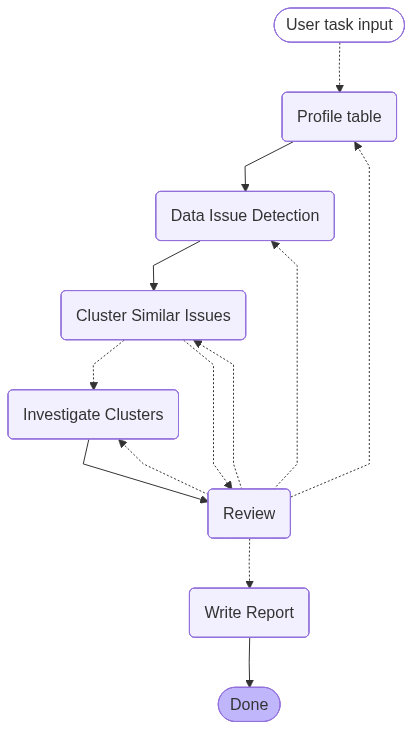

In [8]:
import re
from IPython.display import Image
from langchain_core.runnables.graph_mermaid import draw_mermaid_png

# Display labels for graph nodes (node IDs stay unchanged, only the rendered text).
LABELS = {
    "__start__": "User task input",
    "__end__": "Done"
}

# Nodes hidden from the diagram — incoming/outgoing edges are spliced together.
HIDE = {"Context Ingestion"}

EDGE_RE = re.compile(r"^\t(\S+) (-->|-\.->) (\S+);$")


def hide_nodes(src: str, hidden: set) -> str:
    """Drop nodes from mermaid source, reconnecting predecessors to successors."""
    ids = [n.replace(" ", "\\20") for n in hidden]   # langgraph escapes spaces in node IDs
    edges, skeleton = [], []
    for line in src.splitlines():
        m = EDGE_RE.match(line)
        if m:
            if not edges:
                skeleton.append("__EDGES__")         # remember where the edge block sits
            edges.append(list(m.groups()))
        else:
            skeleton.append(line)
    for h in ids:
        ins = [e for e in edges if e[2] == h]
        outs = [e for e in edges if e[0] == h]
        edges = [e for e in edges if h not in (e[0], e[2])]
        for i in ins:
            for o in outs:                           # splice through: pred -> succ,
                arrow = "-.->" if "-.->" in (i[1], o[1]) else "-->"  # dotted if either leg was
                if [i[0], arrow, o[2]] not in edges:
                    edges.append([i[0], arrow, o[2]])
        skeleton = [l for l in skeleton if not l.lstrip("\t").startswith(f"{h}(")]
    return "\n".join(
        line if line != "__EDGES__"
        else "\n".join(f"\t{s} {a} {d};" for s, a, d in edges)
        for line in skeleton
    )


mermaid_src = graph.get_graph().draw_mermaid()
mermaid_src = hide_nodes(mermaid_src, HIDE)
for node, label in LABELS.items():
    mermaid_src = mermaid_src.replace(f"<p>{node}</p>", f"<p>{label}</p>")

Image(draw_mermaid_png(mermaid_syntax=mermaid_src))

In [6]:
import operator
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langgraph.checkpoint.memory import InMemorySaver

# ---------- State ----------
def merge_dict(a, b): return {**a, **b}

class DQAState(TypedDict, total=False):
  run_id: str
  tables: list
  etl_index: dict
  expectations: dict
  profiles:       Annotated[dict, merge_dict]          # parallel
  issues: list
  clusters: list
  investigations: Annotated[list, operator.add]        # parallel
  review: dict
  report_path: str
  log:            Annotated[list, operator.add]         # append-only log
  revision_counts: dict
  backtracks: int
  table: str        # per-branch payload from Send()
  cluster: dict     # per-branch payload from Send()

# ---------- Nodes (STUBS — swap bodies for real MCP/Bedrock calls) ----------
def ingest_context(state):
  etl_index = {t: {"load_proc": f"etl/procedures/etl.load_{t}.sql"} for t in state["tables"]}
  expectations = {t: {"columns": {}} for t in state["tables"]}
  return {"etl_index": etl_index, "expectations": expectations,
          "log": [f"phase0: indexed {len(state['tables'])} tables"]}

def profile_table(state):
  t = state["table"]
  return {"profiles": {t: {"row_count": 1000}}, "log": [f"phase1: profiled {t}"]}

def detect_issues(state):
  issues = [{"issue_id": "DEM-001", "table": "DEMOGRAPHIC", "severity": "critical"},
            {"issue_id": "ENC-007", "table": "ENCOUNTER", "severity": "info"}]
  return {"issues": issues, "log": [f"phase2: detected {len(issues)} issues"]}

def cluster_issues(state):
  clusters = [{"cluster_id": "C-1", "issues": ["DEM-001"], "investigation_priority": "high"},
              {"cluster_id": "C-2", "issues": ["ENC-007"], "investigation_priority": "low"}]
  return {"clusters": clusters, "log": [f"phase3: {len(clusters)} clusters"]}

def investigate_cluster(state):
  c = state["cluster"]
  # In the real system this is the AUTONOMOUS agent loop over etl_reader/sql_executor/doc_search.
  result = {"cluster_id": c["cluster_id"], "root_cause": "stub", "confidence": "high"}
  return {"investigations": [result], "log": [f"phase4: investigated {c['cluster_id']}"]}

def review(state):
  verdict = {"verdict": "ACCEPT", "target_phase": None}
  return {"review": verdict, "log": [f"phase5: verdict={verdict['verdict']}"]}

def write_report(state):
  return {"report_path": f"results/{state['run_id']}/dqa_report.md",
          "log": ["phase6: report written"]}

NODES = {"Context Ingestion": ingest_context, "Profile table": profile_table,
       "Data Issue Detection": detect_issues, "Cluster Similar Issues": cluster_issues,
       "Investigate Clusters": investigate_cluster, "Review": review,
       "Write Report": write_report}

# ---------- Routers ----------
def fan_out_profilers(state):
  return [Send("Profile table", {**state, "table": t}) for t in state["tables"]]

def fan_out_investigators(state):
  todo = [c for c in state["clusters"] if c["investigation_priority"] in ("high", "medium")]
  skipped = [c["cluster_id"] for c in state["clusters"] if c not in todo]
  print(f"  [router] investigating {[c['cluster_id'] for c in todo]}, skipping low-priority {skipped}")
  return ([Send("Investigate Clusters", {**state, "cluster": c}) for c in todo]
          or [Send("Review", state)])

def route_after_review(state):
  v = state["review"]
  if v["verdict"] == "ACCEPT": return "Write Report"
  if v["verdict"] == "REJECT": return "Context Ingestion"
  target = v["target_phase"]
  capped = state["revision_counts"].get(target, 0) >= 3 or state["backtracks"] >= 2
  return "Write Report" if capped else target

# ---------- Wiring ----------
b = StateGraph(DQAState)
for name, fn in NODES.items(): b.add_node(name, fn)
b.add_edge(START, "Context Ingestion")
b.add_conditional_edges("Context Ingestion", fan_out_profilers, ["Profile table"])
b.add_edge("Profile table", "Data Issue Detection")                  # barrier
b.add_edge("Data Issue Detection", "Cluster Similar Issues")
b.add_conditional_edges("Cluster Similar Issues", fan_out_investigators,
                      ["Investigate Clusters", "Review"])
b.add_edge("Investigate Clusters", "Review")                         # barrier
b.add_conditional_edges("Review", route_after_review,
                      ["Write Report", "Context Ingestion", "Data Issue Detection",
                       "Cluster Similar Issues", "Investigate Clusters"])
b.add_edge("Write Report", END)
graph = b.compile(checkpointer=InMemorySaver())

# ---------- Run it ----------
initial = {"run_id": "2026-06-01_cdw_dqa",
         "tables": ["DEMOGRAPHIC", "ENCOUNTER", "DIAGNOSIS"],
         "profiles": {}, "investigations": [], "log": [],
         "revision_counts": {}, "backtracks": 0}
final = graph.invoke(initial, config={"configurable": {"thread_id": "demo-run"}})

print("\nreport_path    :", final["report_path"])
print("profiles       :", sorted(final["profiles"]))
print("investigations :", [i["cluster_id"] for i in final["investigations"]])
print("\n--- decision log ---")
for line in final["log"]: print("  -", line)

  [router] investigating ['C-1'], skipping low-priority ['C-2']

report_path    : results/2026-06-01_cdw_dqa/dqa_report.md
profiles       : ['DEMOGRAPHIC', 'DIAGNOSIS', 'ENCOUNTER']
investigations : ['C-1']

--- decision log ---
  - phase0: indexed 3 tables
  - phase1: profiled DEMOGRAPHIC
  - phase1: profiled ENCOUNTER
  - phase1: profiled DIAGNOSIS
  - phase2: detected 2 issues
  - phase3: 2 clusters
  - phase4: investigated C-1
  - phase5: verdict=ACCEPT
  - phase6: report written


## Cloudflare sandboxing

**Milestone 3:** swap the in-process `eval` for real, VM-isolated execution. The
`run_python` tool below sends code to the `dqa-sandbox-runner` Worker (see
`sandbox-worker/`), which runs it in a Cloudflare Sandbox container and returns
stdout / stderr / rich results. The agent loop is unchanged — only the tool body
moves off this machine.

Deploy the Worker first, then point the notebook at it:

```bash
cd sandbox-worker
npm install
npx wrangler secret put SANDBOX_SHARED_SECRET   # choose a long random value
npm run deploy                                   # first deploy builds the
                                                 # container image (a few minutes)
```

Add the two vars to `.env` (next to this notebook) and re-run the section-2
`.env` cell so they load:

```
SANDBOX_WORKER_URL=https://dqa-sandbox-runner.<your-subdomain>.workers.dev
SANDBOX_SHARED_SECRET=<the same secret you set via `wrangler secret put`>
```

> Note: `import { getSandbox } from '@cloudflare/sandbox'` is TypeScript and
> lives in the Worker (`sandbox-worker/src/index.ts`), not this Python notebook.
> From Python we just call the Worker over HTTP — that's what the next cell does.


In [7]:
import os
import requests
from langchain_core.tools import tool

SANDBOX_URL = os.environ["SANDBOX_WORKER_URL"]        # https://dqa-sandbox-runner.<sub>.workers.dev
SANDBOX_SECRET = os.environ["SANDBOX_SHARED_SECRET"]


@tool
def run_python(code: str) -> str:
    """Execute Python code in an isolated Cloudflare sandbox and return its output.

    Runs in a remote VM-isolated container, NOT in this process. Use this for any
    real computation or code the user asks you to run. Print anything you want to
    see in the result.
    """
    resp = requests.post(
        SANDBOX_URL,
        headers={"Authorization": f"Bearer {SANDBOX_SECRET}"},
        json={"code": code, "language": "python"},
        timeout=120,
    )
    resp.raise_for_status()
    data = resp.json()
    if data.get("error"):
        err = data["error"]
        return f"Error: {err['name']}: {err['value']}"
    texts = [r["text"] for r in data.get("results", []) if r.get("text")]
    return "\n".join(filter(None, [data.get("stdout", ""), *texts])).strip() or "(no output)"


# Rebuild the agent with the sandboxed executor instead of the in-process eval.
agent = create_react_agent(model=llm, tools=[run_python, get_weather])

# Smoke test — real Python, executed remotely in the sandbox:
for chunk in agent.stream(
    {"messages": [("user", "Compute the 20th Fibonacci number in Python.")]},
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()


/tmp/ipykernel_205961/1748873122.py:33: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(model=llm, tools=[run_python, get_weather])


================================ Human Message =================================

Compute the 20th Fibonacci number in Python.
================================== Ai Message ==================================

[{'type': 'text', 'text': "I'll compute the 20th Fibonacci number for you using Python."}, {'type': 'tool_use', 'name': 'run_python', 'input': {'code': '\ndef fibonacci(n):\n    """Compute the nth Fibonacci number"""\n    if n <= 0:\n        return 0\n    elif n == 1:\n        return 1\n    else:\n        a, b = 0, 1\n        for _ in range(2, n + 1):\n            a, b = b, a + b\n        return b\n\n# Compute the 20th Fibonacci number\nresult = fibonacci(20)\nprint(f"The 20th Fibonacci number is: {result}")\n'}, 'id': 'tooluse_8py0TcwbhmpgZn2RgOFkq3'}]
Tool Calls:
  run_python (tooluse_8py0TcwbhmpgZn2RgOFkq3)
 Call ID: tooluse_8py0TcwbhmpgZn2RgOFkq3
  Args:
    code: 
def fibonacci(n):
    """Compute the nth Fibonacci number"""
    if n <= 0:
        return 0
    elif n == 1:
   